In [2]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from scipy.stats import linregress

In [3]:
# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

In [4]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths)

In [5]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
#print("\nFiltered files:")
#print(filtered_files)


In [6]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_ams)

In [7]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_sp2)

In [8]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_dry_neph)

In [9]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_dry_neph)

In [10]:
# Initialize a list to store file paths
file_paths_flight_sum = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/flight-sum*.txt"
    file_paths_flight_sum.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_flight_sum)

In [11]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}
flights_neph = {extract_flight_number(f) for f in file_paths_dry_neph}
flights_sum = {extract_flight_number(f) for f in file_paths_flight_sum}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in file_paths_dry_neph if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in file_paths_flight_sum if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [12]:
filtered_sp2[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_sp2[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

20120918


In [13]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("datetime", datetime_values))
    dsf["Times"] = (("time",), datetime_values)

    return dsf

In [14]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [15]:
def Test_function(aux_ds_ams,aux_ds_psap,aux_ds_sp2):
    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ds = filtered_ds.resample(datetime="1min").mean()
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ds[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc
    #print(total_mass)
    # Compute mass fractions and store in a new dataset
    mass_fraction_ds_ams = xr.Dataset({
        f"{var}_fraction": resampled_ds[var] / total_mass
        for var in variables
    })

    for var in variables:
        mass_fraction_ds_ams[f"{var}_fraction"].attrs["units"] = "unitless"
        mass_fraction_ds_ams[f"{var}_fraction"].attrs["description"] = f"Mass fraction of {var}"
    
    # Compute mass fractions and store in a new dataset
    mass_fraction_ds_sp2 = xr.Dataset({
        f"{var}_fraction": resampled_ds_sp2[var] / total_mass
        for var in components
    })

    for var in components:
        mass_fraction_ds_sp2[f"{var}_fraction"].attrs["units"] = "unitless"
        mass_fraction_ds_sp2[f"{var}_fraction"].attrs["description"] = f"Mass fraction of {var}"
    
    return resampled_ds,resampled_psap,mass_fraction_ds_ams,mass_fraction_ds_sp2


In [16]:
def Test_function_v2(aux_ds_ams,aux_ds_neph,aux_ds_sp2):
    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ds = filtered_ds.resample(datetime="1min").mean()
    resampled_neph = aux_ds_neph.resample(Times='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ds[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc
    #print(total_mass)
    # Compute mass fractions and store in a new dataset
    mass_fraction_ds_ams = xr.Dataset({
        f"{var}_fraction": resampled_ds[var] / total_mass
        for var in variables
    })

    for var in variables:
        mass_fraction_ds_ams[f"{var}_fraction"].attrs["units"] = "unitless"
        mass_fraction_ds_ams[f"{var}_fraction"].attrs["description"] = f"Mass fraction of {var}"
    
    # Compute mass fractions and store in a new dataset
    mass_fraction_ds_sp2 = xr.Dataset({
        f"{var}_fraction": resampled_ds_sp2[var] / total_mass
        for var in components
    })

    for var in components:
        mass_fraction_ds_sp2[f"{var}_fraction"].attrs["units"] = "unitless"
        mass_fraction_ds_sp2[f"{var}_fraction"].attrs["description"] = f"Mass fraction of {var}"
    
    return resampled_ds,resampled_neph,mass_fraction_ds_ams,mass_fraction_ds_sp2

In [17]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[0],filtered_ams[0],filtered_neph[0])

In [18]:
ds_ams

<xarray.Dataset> Size: 99kB
Dimensions:          (time: 821)
Coordinates:
  * time             (time) int64 7kB 0 1 2 3 4 5 6 ... 815 816 817 818 819 820
    datetime         (time) datetime64[ns] 7kB 2012-09-18T12:41:28 ... 2012-0...
Data variables: (12/13)
    Time_start_UTC   (time) float64 7kB 4.569e+04 4.572e+04 ... 6.262e+04
    Time_end_UTC     (time) float64 7kB 4.572e+04 4.575e+04 ... 6.263e+04
    Time_mid_UTC     (time) float64 7kB 4.57e+04 4.574e+04 ... 6.263e+04
    SO4              (time) float64 7kB 0.5045 0.4973 0.4592 ... 1e+07 1e+07
    NH4              (time) float64 7kB 0.2257 0.3432 0.0238 ... 1e+07 1e+07
    ORG              (time) float64 7kB 0.7897 1.233 0.2763 ... 1e+07 1e+07
    ...               ...
    Chl              (time) float64 7kB 0.06375 0.01435 0.02502 ... 1e+07 1e+07
    SO4_uncertainty  (time) float64 7kB 0.05692 0.0478 0.0484 ... 1e+07 1e+07
    NH4_uncertainty  (time) float64 7kB 0.2079 0.164 0.163 ... 1e+07 1e+07 1e+07
    ORG_uncertainty  (time) float64 7kB 0.3488 0.2755 0.2742 ... 1e+07 1e+07
    NO3_uncertainty  (time) float64 7kB 0.07126 0.05653 0.05552 ... 1e+07 1e+07
    Chl_uncertainty  (time) float64 7kB 0.03404 0.02763 0.02715 ... 1e+07 1e+07
Attributes:
    Metadata:  46 1001\nWill Morgan, James Allan\nSchool of Earth, Atmospheri...

In [19]:
ds_test,neph,mass_frac,mass_frac_sp2 = Test_function_v2(ds_ams,ds_neph,ds_sp2)


In [20]:
ds_test

<xarray.Dataset> Size: 23kB
Dimensions:          (time: 201)
Coordinates:
  * time             (time) datetime64[ns] 2kB 2012-09-18T12:41:00 ... 2012-0...
Data variables: (12/13)
    Time_start_UTC   (time) float64 2kB 4.569e+04 4.574e+04 ... 5.767e+04
    Time_end_UTC     (time) float64 2kB 4.572e+04 4.577e+04 ... 5.768e+04
    Time_mid_UTC     (time) float64 2kB 4.57e+04 4.575e+04 ... 5.768e+04
    SO4              (time) float64 2kB 0.5045 0.4782 nan ... 1.353 1.284 1.206
    NH4              (time) float64 2kB 0.2257 0.1835 nan ... 0.5066 0.3224
    ORG              (time) float64 2kB 0.7897 0.7548 nan ... 9.74 9.661 8.846
    ...               ...
    Chl              (time) float64 2kB 0.06375 0.01968 nan ... 0.03382 0.004224
    SO4_uncertainty  (time) float64 2kB 0.05692 0.0481 nan ... 0.04673 0.04553
    NH4_uncertainty  (time) float64 2kB 0.2079 0.1635 nan ... 0.09381 0.09201
    ORG_uncertainty  (time) float64 2kB 0.3488 0.2749 nan ... 0.1618 0.1581
    NO3_uncertainty  (time) float64 2kB 0.07126 0.05603 nan ... 0.02879 0.02754
    Chl_uncertainty  (time) float64 2kB 0.03404 0.02739 nan ... 0.01512 0.01494
Attributes:
    Metadata:  46 1001\nWill Morgan, James Allan\nSchool of Earth, Atmospheri...

In [21]:

time_neph = neph['time']
time_mass_ams = mass_frac['time']
time_mass_sp2 = mass_frac_sp2['time']

matching_times_ams = np.intersect1d(time_mass_ams.values, time_neph.values)
matching_times_sp2 = np.intersect1d(time_mass_sp2.values, time_neph.values)


# Step 3: Select only matching times from both datasets
mass_fraction_aligned_ams = mass_frac.sel(time=matching_times_ams)
neph_aligned_ams = neph.sel(time=matching_times_ams)
# Step 3: Select only matching times from both datasets
mass_fraction_aligned_sp2 = mass_frac_sp2.sel(time=matching_times_sp2)
neph_aligned_sp2 = neph.sel(time=matching_times_sp2)


In [26]:
neph_aligned_ams

<xarray.Dataset> Size: 137kB
Dimensions:   (time: 140, datetime: 15467)
Coordinates:
  * datetime  (datetime) datetime64[ns] 124kB 2012-10-03T17:42:10 ... 2012-10...
  * time      (time) datetime64[ns] 1kB 2012-10-03T19:14:00 ... 2012-10-03T21...
Data variables:
    neph_spm  (time) float64 1kB 6.927e+04 6.933e+04 ... 7.755e+04 7.761e+04
    TSC_BLUU  (time) float64 1kB 4.637e-05 4.677e-05 ... 2.489e-05 2.597e-05
    TSC_GRNU  (time) float64 1kB 3.236e-05 3.282e-05 ... 1.831e-05 1.83e-05
    TSC_REDU  (time) float64 1kB 1.967e-05 2.007e-05 ... 1.152e-05 1.18e-05
    BSC_BLUU  (time) float64 1kB 5.275e-06 5.318e-06 ... 2.976e-06 3.052e-06
    BSC_GRNU  (time) float64 1kB 4.514e-06 4.541e-06 ... 2.488e-06 2.62e-06
    BSC_REDU  (time) float64 1kB 4.018e-06 3.85e-06 ... 2.059e-06 2.748e-06
    NEPH_PR   (time) float64 1kB 996.5 1.005e+03 ... 1.042e+03 1.041e+03
    NEPH_T    (time) float64 1kB 308.6 308.7 308.7 308.8 ... 307.3 307.4 307.4
    NEPH_HUM  (time) float64 1kB 57.89 57.97 58.96 57.05 ... 52.62 52.83 54.81
    NEPH_FLO  (time) float64 1kB 15.0 15.0 15.0 15.0 ... 15.0 15.0 15.0 15.0
Attributes:
    description:  Dry neph data NetCDF from SAMBBA. Note neph data in the cor...
    conventions:  NetCDF4
    title:        Dry neph data (some differences from usual core data - ask ...
    institution:  Data provided by the Met Office (recorded via wet neph).
    history:      Created Thu Mar 14 11:58:53 2013
    references:   Anderson and Ogren, AST, 1998 for details on corrections. 
    data_date:    20121003
    sample_line:  Inlet -> nafion drier -> dry neph -> humidifier -> wet neph...
    comment:      Note that the Met Office TSI3563 was used in place of the F...

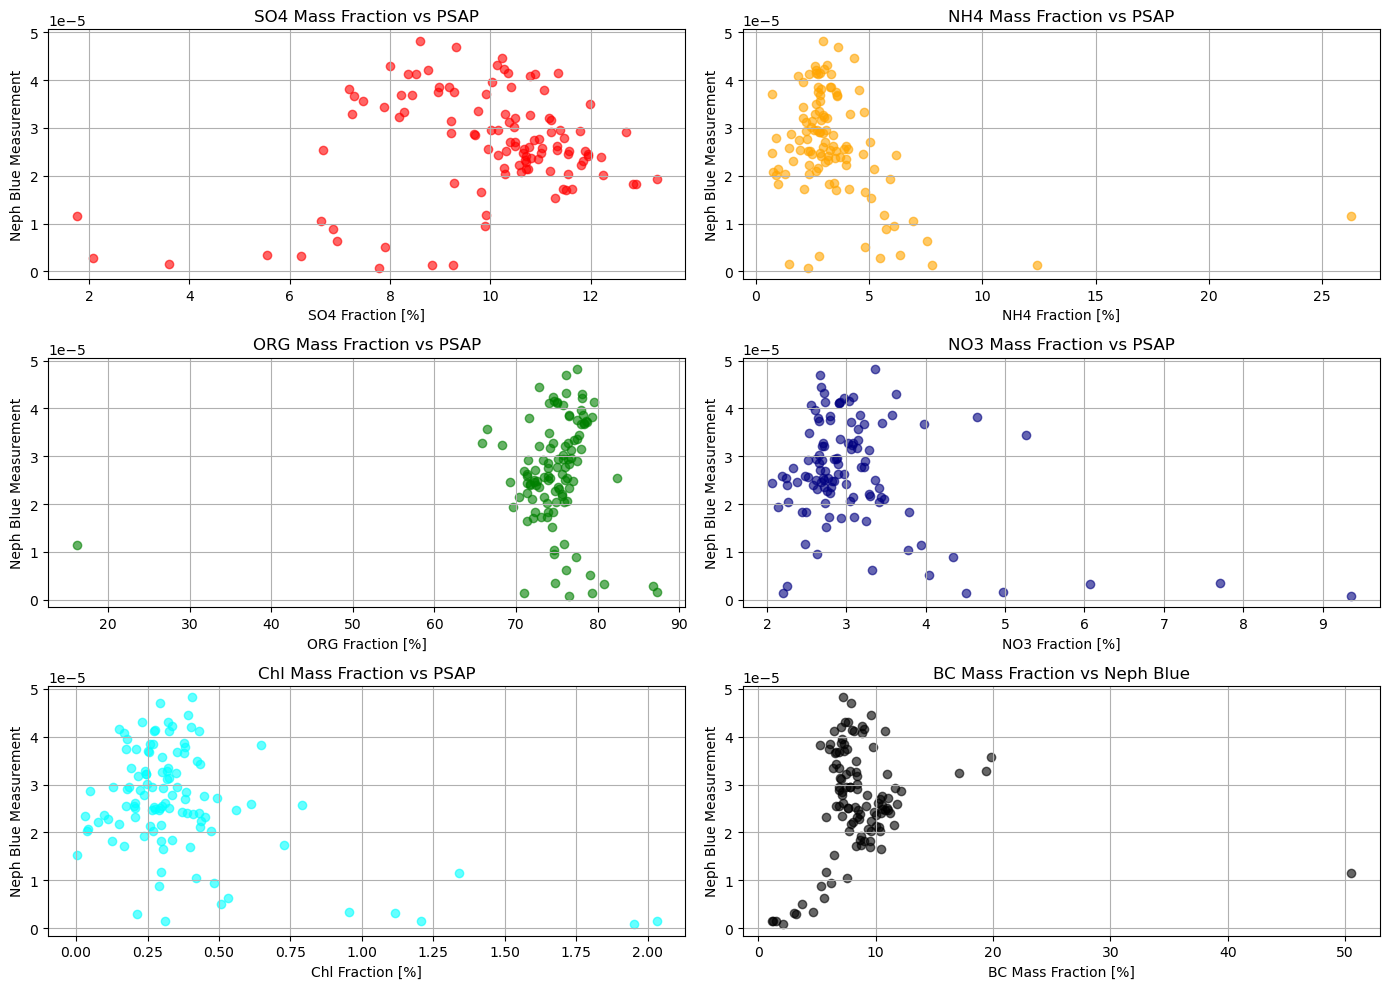

In [29]:
neph_var = "TSC_REDU"  # Replace with the actual variable name in psap_aligned
components = ["SO4", "NH4", "ORG", "NO3","Chl"]
colors = {
    "SO4": "red",
    "NH4": "orange",
    "ORG": "green",
    "NO3": "navy",
    "Chl": "cyan"
}

# Create subplots (3 rows x 2 cols to fit 5 plots nicely)
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
axs = axs.flatten()

for i, var in enumerate(components):
    ax = axs[i]
    x = mass_fraction_aligned_ams[f"{var}_fraction"]* 100  
    y = neph_aligned_ams[neph_var]

    ax.scatter(x, y, color=colors[var], alpha=0.6)
    ax.set_title(f"{var} Mass Fraction vs PSAP", fontsize=12)
    ax.set_xlabel(f"{var} Fraction [%]")
    ax.set_ylabel("Neph Blue Measurement")
    ax.grid(True)

# Plot BC_mass_fraction from another dataset
ax = axs[len(components)]
x = mass_fraction_aligned_sp2["BC_mass_fraction"]* 100
y = neph_aligned_sp2[neph_var]

ax.scatter(x, y, color='black', alpha=0.6)
ax.set_title("BC Mass Fraction vs Neph Blue", fontsize=12)
ax.set_xlabel("BC Mass Fraction [%]")
ax.set_ylabel("Neph Blue Measurement")
ax.grid(True)

plt.tight_layout()
plt.show()




In [23]:
def plot_mass_frac_flights(flight_number,flight_date,mass_frac_ams,psap_ams,mass_frac_sp2,psap_sp2):

    neph_var = "TSC_BLUU"  # Replace with the actual variable name in psap_aligned
    components = ["SO4", "NH4", "ORG", "NO3","Chl"]
    colors = {
        "SO4": "red",
        "NH4": "orange",
        "ORG": "green",
        "NO3": "navy",
        "Chl": "cyan"
    }
    
    # Create subplots (3 rows x 2 cols to fit 5 plots nicely)
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
    axs = axs.flatten()
    
    for i, var in enumerate(components):
        ax = axs[i]
        x = mass_fraction_aligned_ams[f"{var}_fraction"]* 100  
        y = psap_ams[neph_var]
    
        ax.scatter(x, y, color=colors[var], alpha=0.6)
        #ax.set_title(f"{var} Mass Fraction vs PSAP", fontsize=12)
        ax.set_xlabel(f"{var} Fraction [%]")
        ax.set_ylabel("Neph Blue Measurement")
        ax.grid(True)
    
    # Plot BC_mass_fraction from another dataset
    ax = axs[len(components)]
    x = mass_fraction_aligned_sp2["BC_mass_fraction"]* 100
    y = psap_sp2[neph_var]
    
    ax.scatter(x, y, color='black', alpha=0.6)
    #ax.set_title("BC Mass Fraction vs PSAP", fontsize=12)
    ax.set_xlabel("BC Mass Fraction [%]")
    ax.set_ylabel("Neph Blue Measurement")
    ax.grid(True)


    # Save and show the figure
    #plt.tight_layout()
    plt.savefig(f'./Mass_Frac_plots/Mass_Frac_{flight_number}_scattering.png', dpi=300)
    print(f"Figure saved as Mass_Frac_{flight_number}_scattering.png")
    #plt.show()

    return

In [34]:
def plot_mass_frac_flights_lin_regress(flight_number,flight_date,mass_frac_ams,psap_ams,mass_frac_sp2,psap_sp2):
    neph_var = "TSC_REDU"  # Replace with the actual variable name in psap_aligned
    components = ["SO4", "NH4", "ORG", "NO3","Chl"]
    colors = {
        "SO4": "red",
        "NH4": "orange",
        "ORG": "green",
        "NO3": "navy",
        "Chl": "cyan"
    }

        # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    
    # Create subplots (3 rows x 2 cols to fit 5 plots nicely)
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
    axs = axs.flatten()
    
    for i, var in enumerate(components):
        ax = axs[i]
        x = mass_fraction_aligned_ams[f"{var}_fraction"] * 100  
        y = psap_ams[neph_var]
        
        y = y.squeeze()
        #print(x.shape)
        #print(y.shape)
        # Remove NaNs for regression
        x_np = x.values.ravel()
        y_np = y.values.ravel()
        
        mask = ~np.isnan(x_np) & ~np.isnan(y_np)
        
        x_clean = x_np[mask]
        y_clean = y_np[mask]
        # Scatter plot
        ax.scatter(x_clean, y_clean, color=colors[var], alpha=0.6)
    
        # Linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
        reg_line = slope * x_clean + intercept
        ax.plot(x_clean, reg_line, color="black", linestyle="--")
    
        # Annotation with stats
        ax.text(0.05, 0.95,
                f"$R^2$ = {r_value**2:.2f}\n"
                f"p = {p_value:.3g}",
                transform=ax.transAxes,
                verticalalignment='top',
                fontsize=9,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

        ax.yaxis.set_major_formatter(formatter)
        ax.set_xlabel(f"{var} Mass Fraction [%]")
        ax.set_ylabel("Dry Neph Red Measurement")
        ax.grid(True)
        #ax.legend()
    
    # Plot for BC mass fraction
    ax = axs[len(components)]
    x = mass_fraction_aligned_sp2["BC_mass_fraction"] * 100
    y = psap_sp2[neph_var]
    
    y = y.squeeze()
    #print(x.shape)
    #print(y.shape)
    # Remove NaNs for regression
    x_np = x.values.ravel()
    y_np = y.values.ravel()
    
    mask = ~np.isnan(x_np) & ~np.isnan(y_np)
    
    x_clean = x_np[mask]
    y_clean = y_np[mask]
    
    ax.scatter(x_clean, y_clean, color='black', alpha=0.6)
    slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
    reg_line = slope * x_clean + intercept
    ax.plot(x_clean, reg_line, color="gray", linestyle="--")
    ax.text(0.05, 0.95,
            f"$R^2$ = {r_value**2:.2f}\n"
            f"p = {p_value:.3g}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))
    
    ax.yaxis.set_major_formatter(formatter)    
    ax.set_xlabel("BC Mass Fraction [%]")
    ax.set_ylabel("Dry Neph Red Measurement")
    ax.grid(True)
    #ax.legend()
    
    # Hide any unused subplots if applicable
    for j in range(len(components)+1, len(axs)):
        fig.delaxes(axs[j])
    

    plt.savefig(f'./Mass_frac_lin_regress_neph/Mass_Frac_lin_regress_{flight_number}_red_scattering.png', dpi=300)
    print(f"Figure saved as Mass_Frac_lin_regress_{flight_number}_red_scattering.png.png")

    return


Figure saved as Mass_Frac_lin_regress_b734_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b737_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b739_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b740_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b741_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b742_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b743_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b744_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b745_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b746_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b747_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b748_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b749_red_scattering.png.png
Figure saved as Mass_Frac_lin_regress_b750_red_scattering.png.png


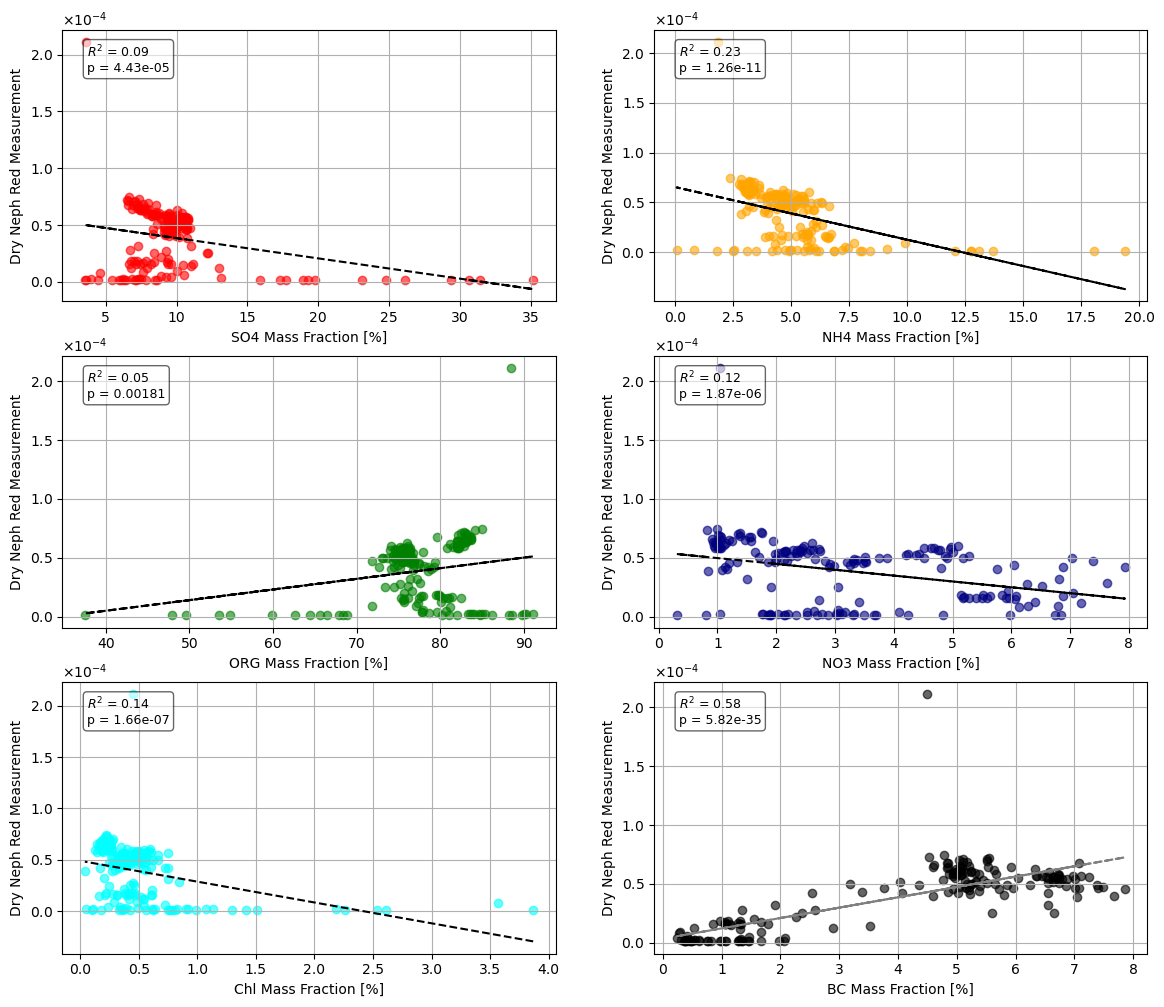

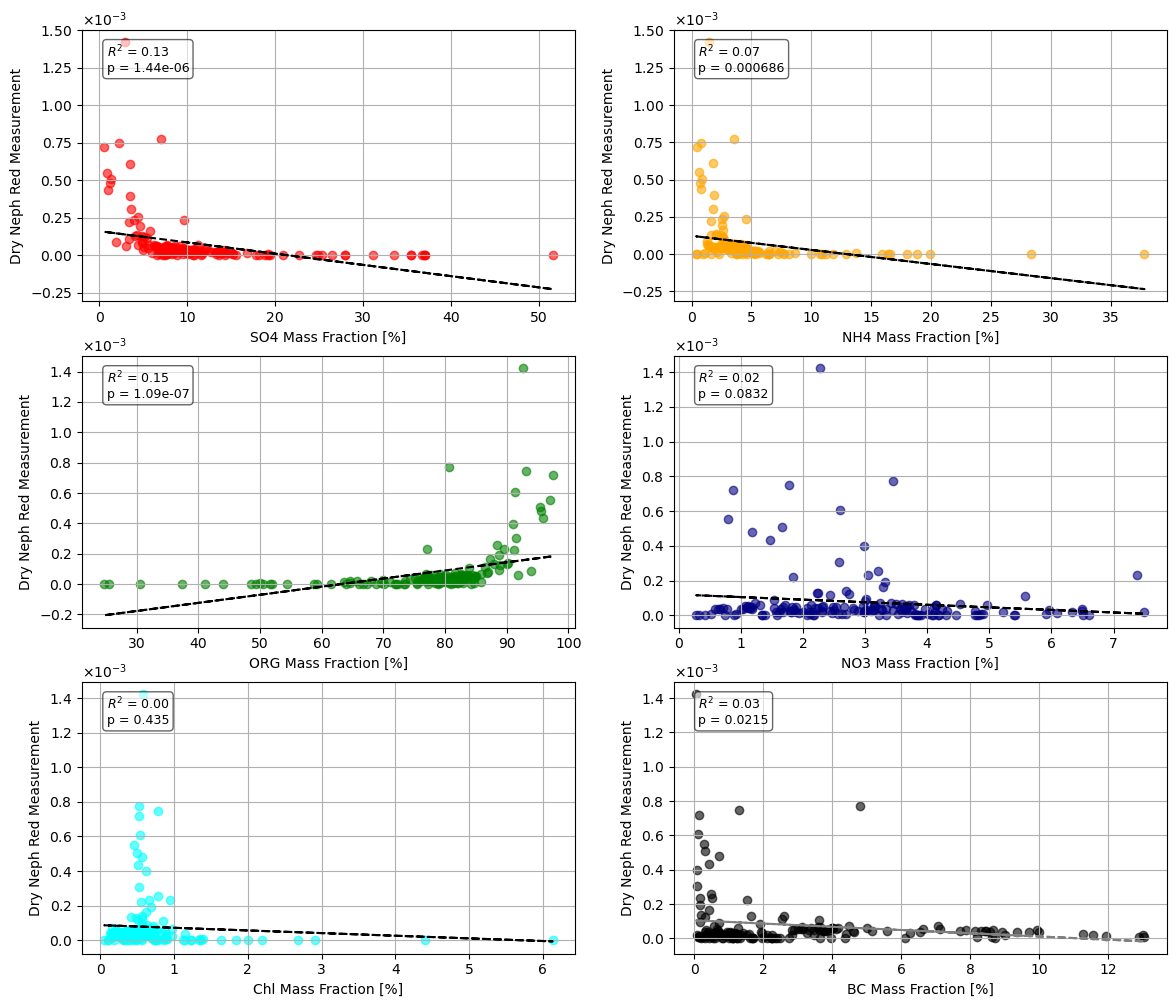

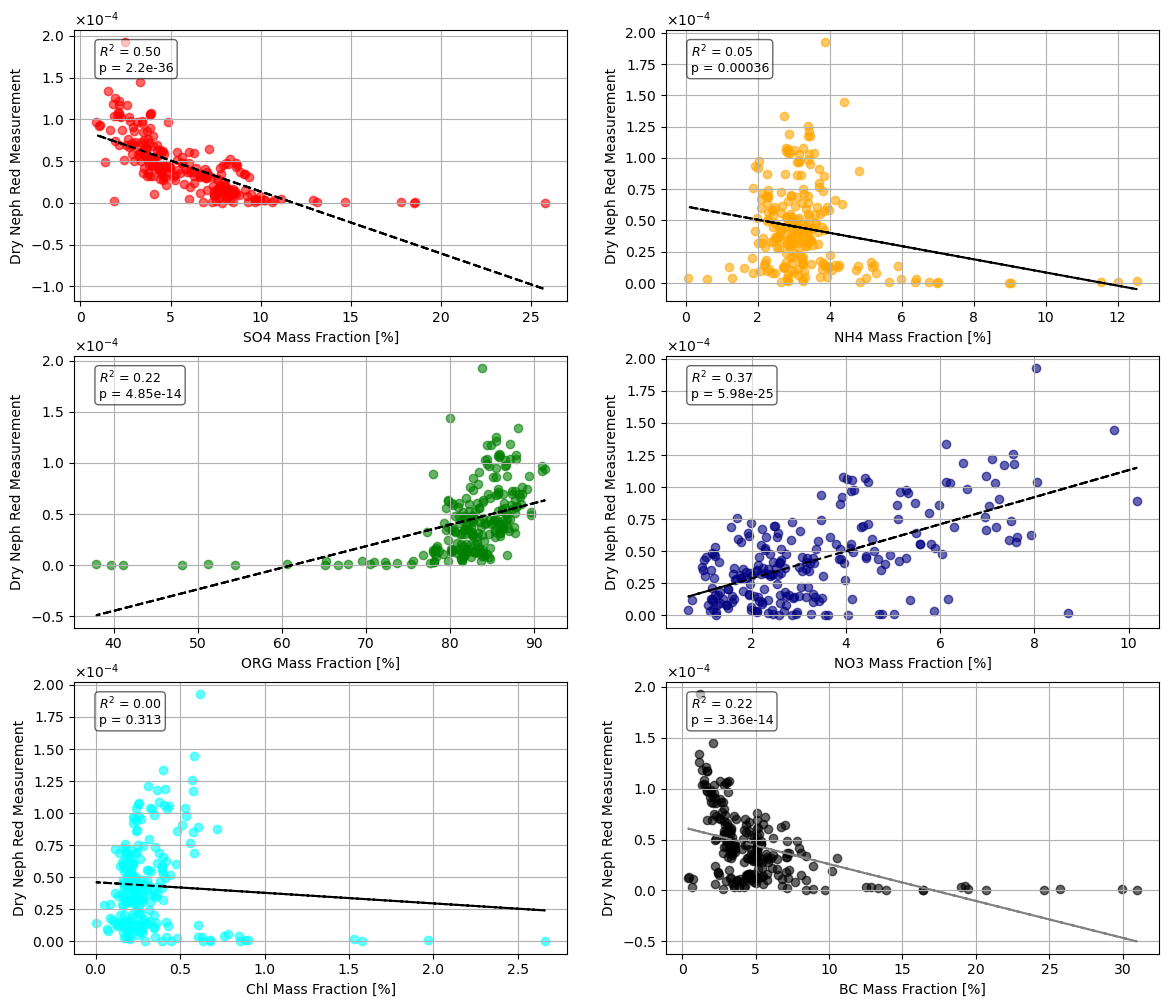

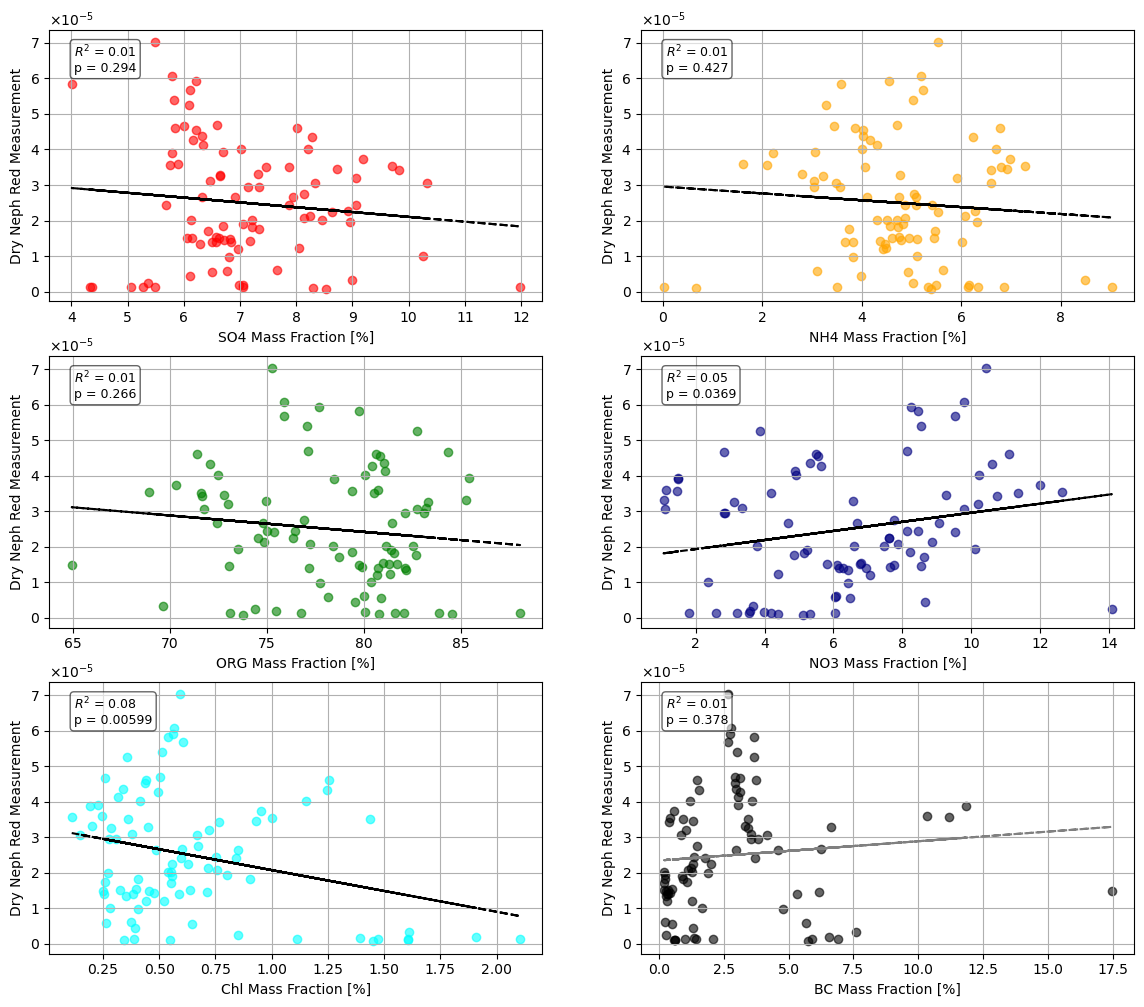

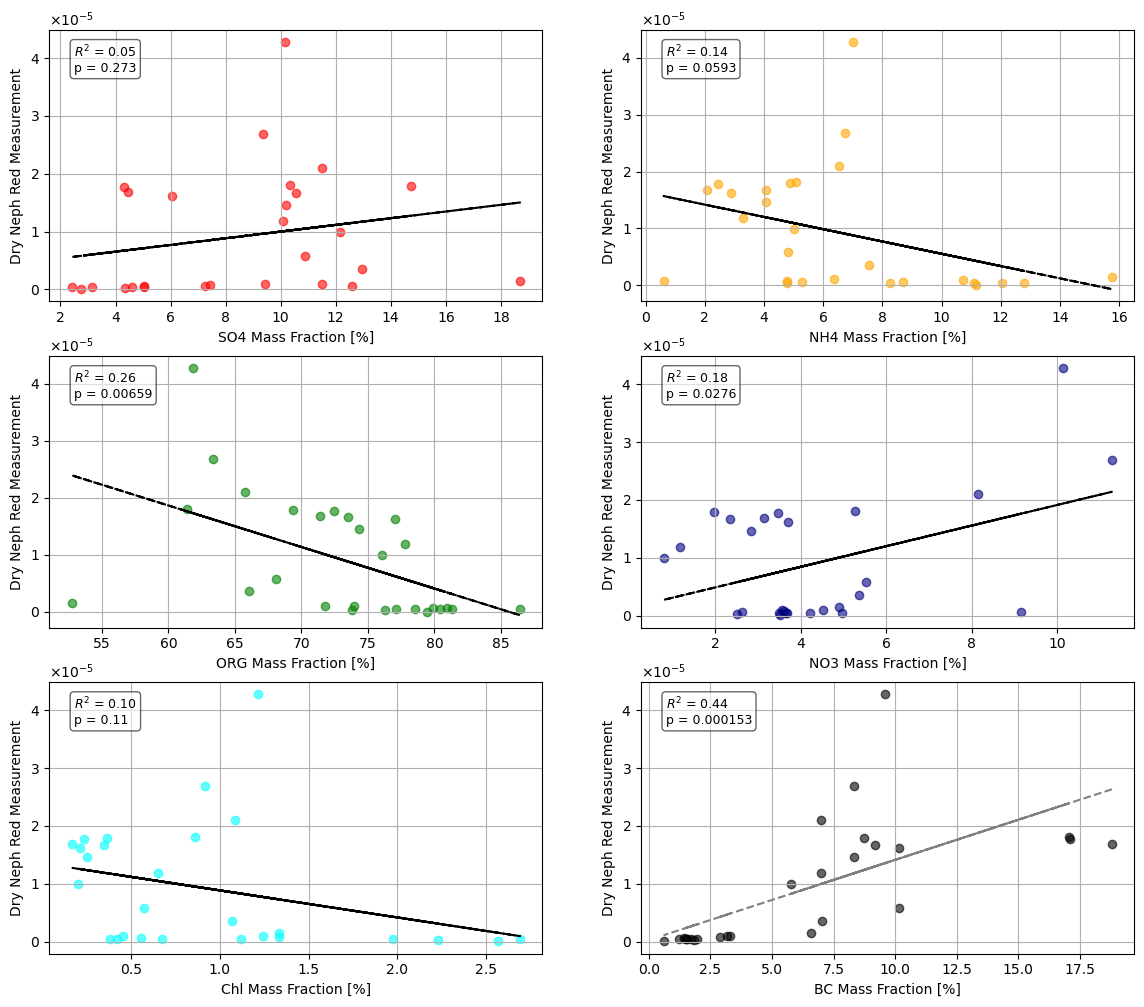

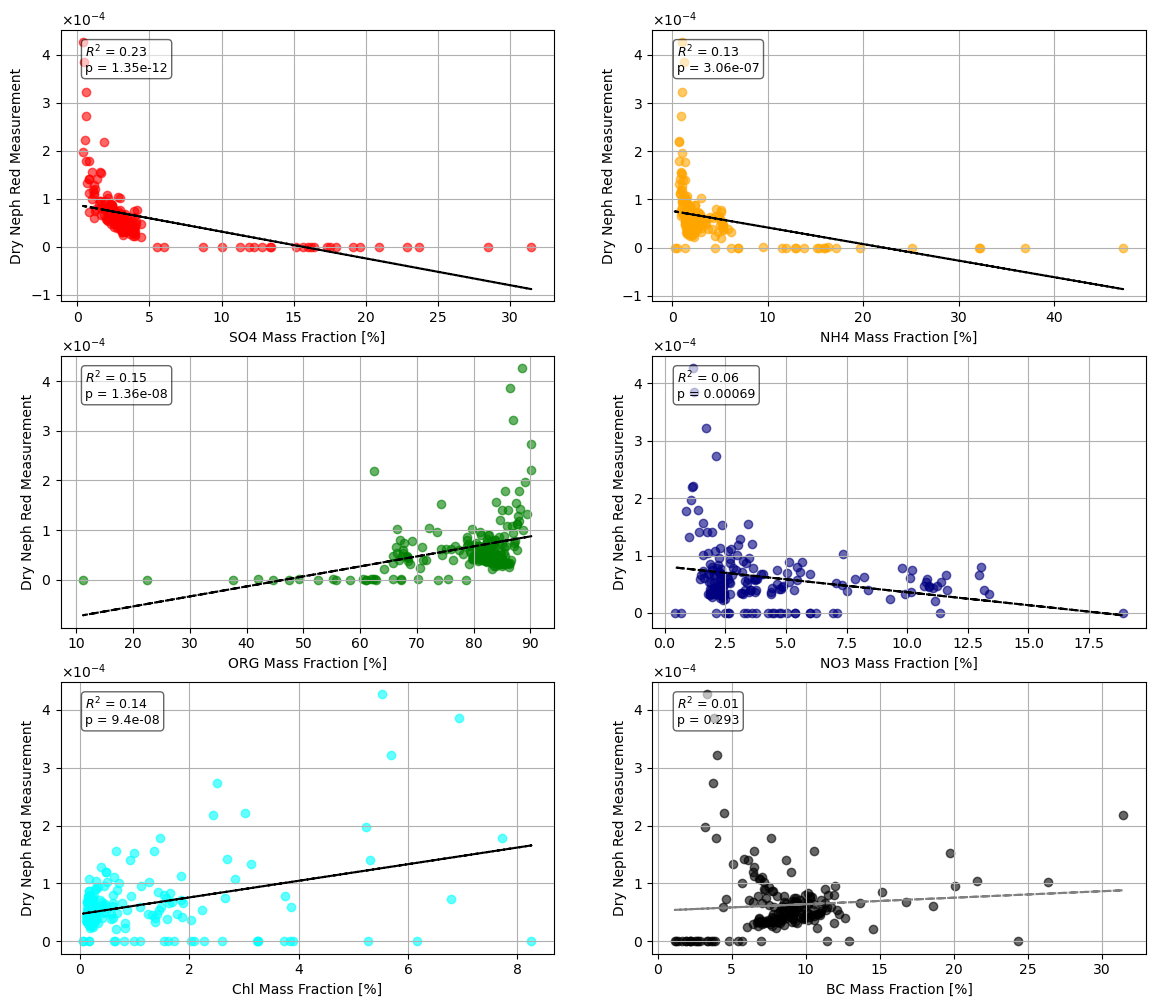

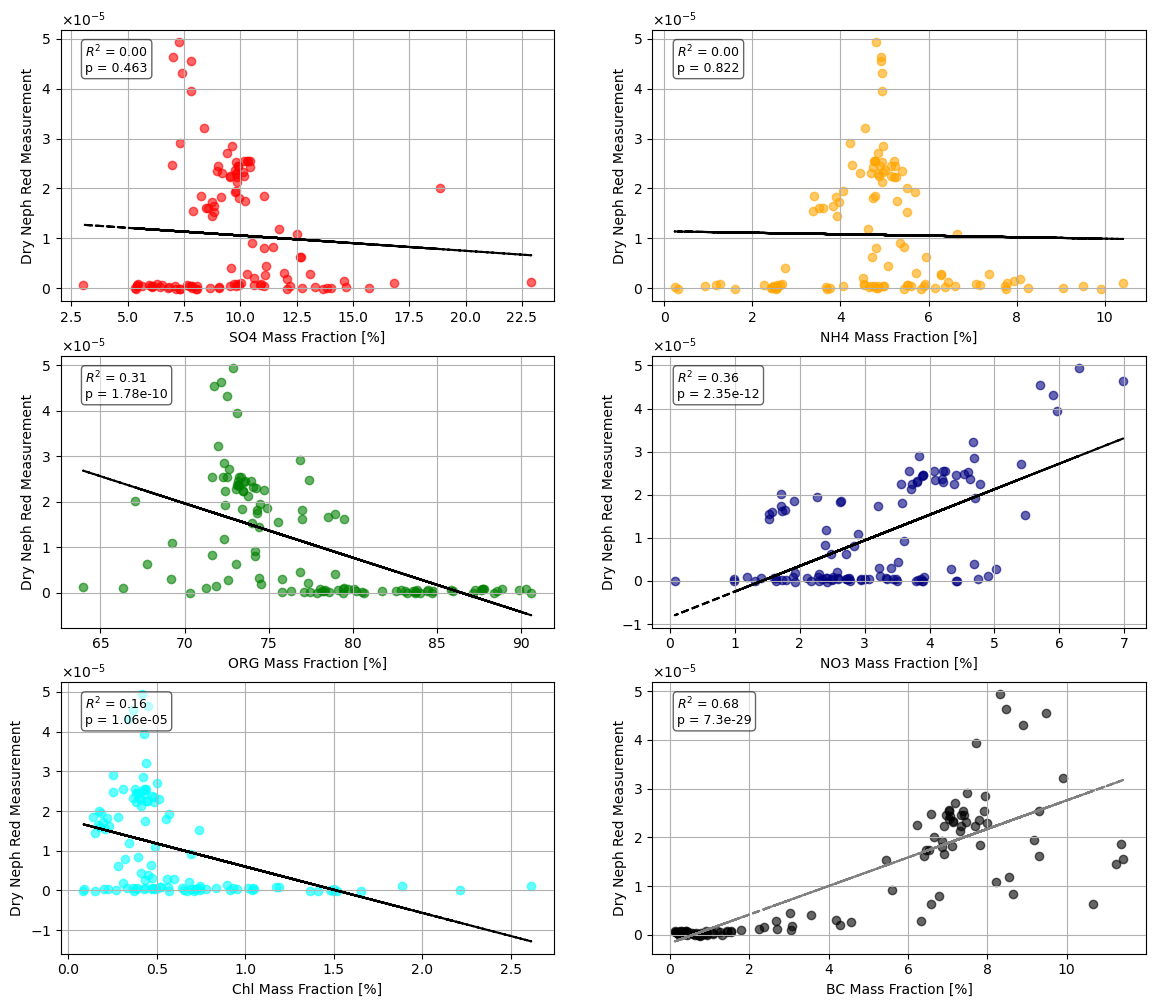

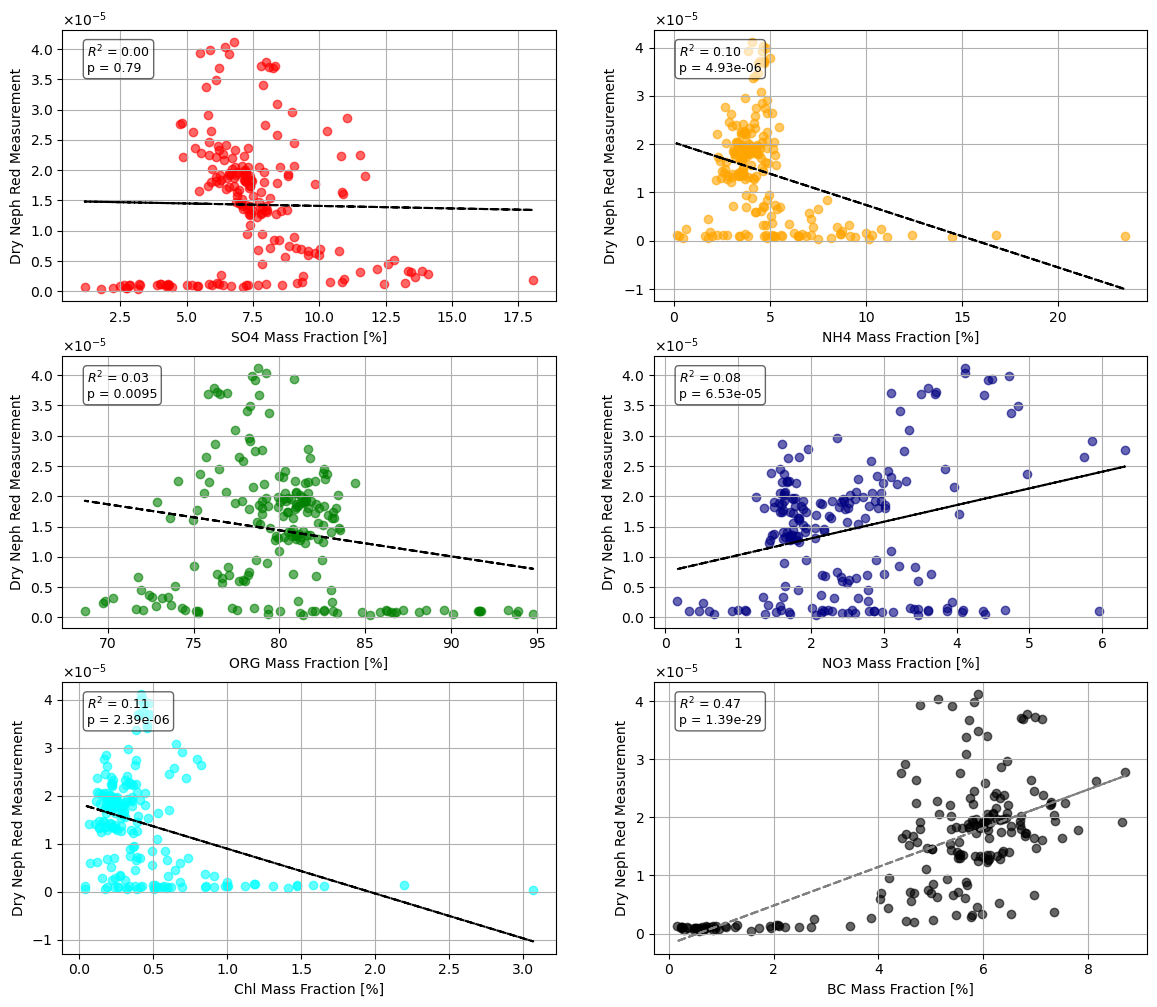

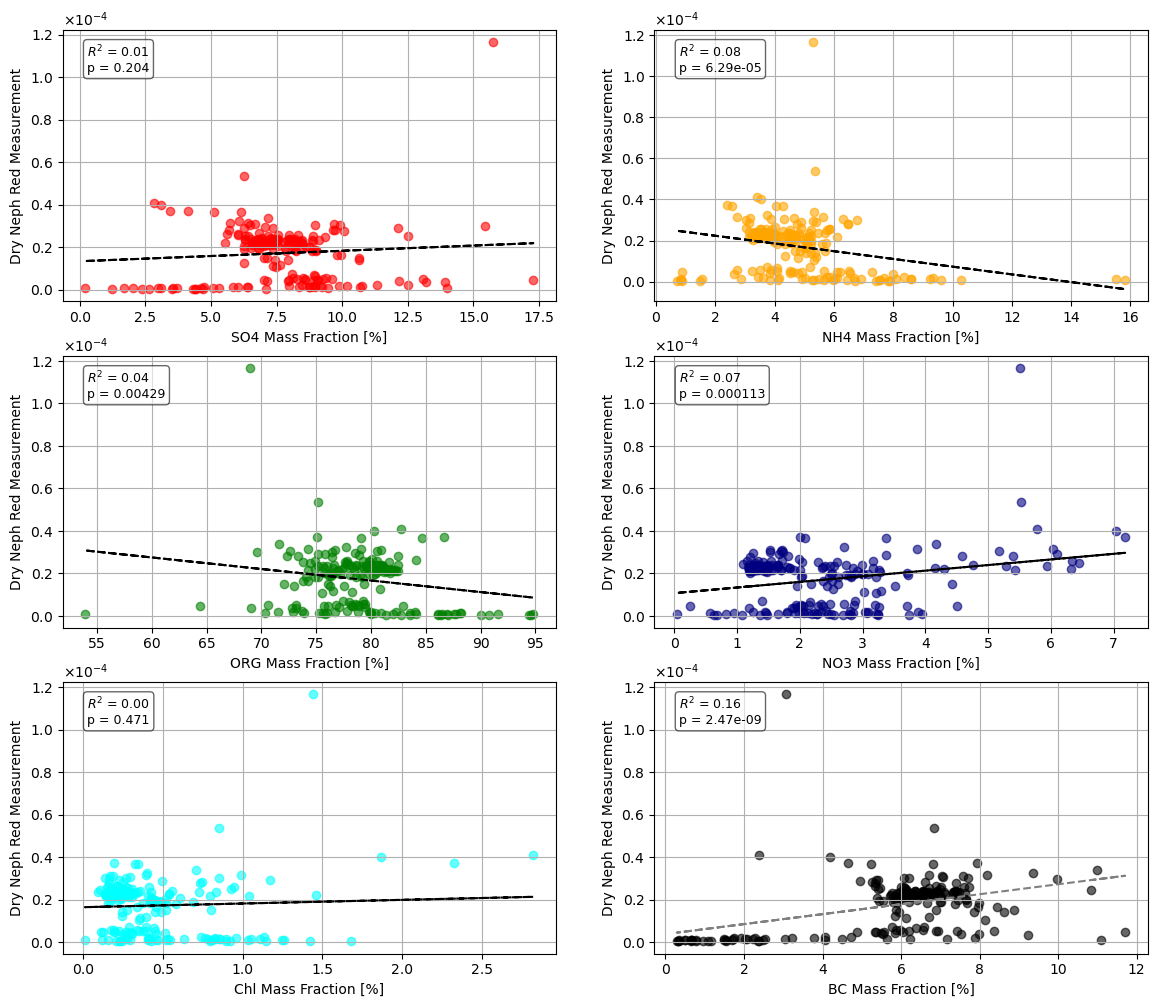

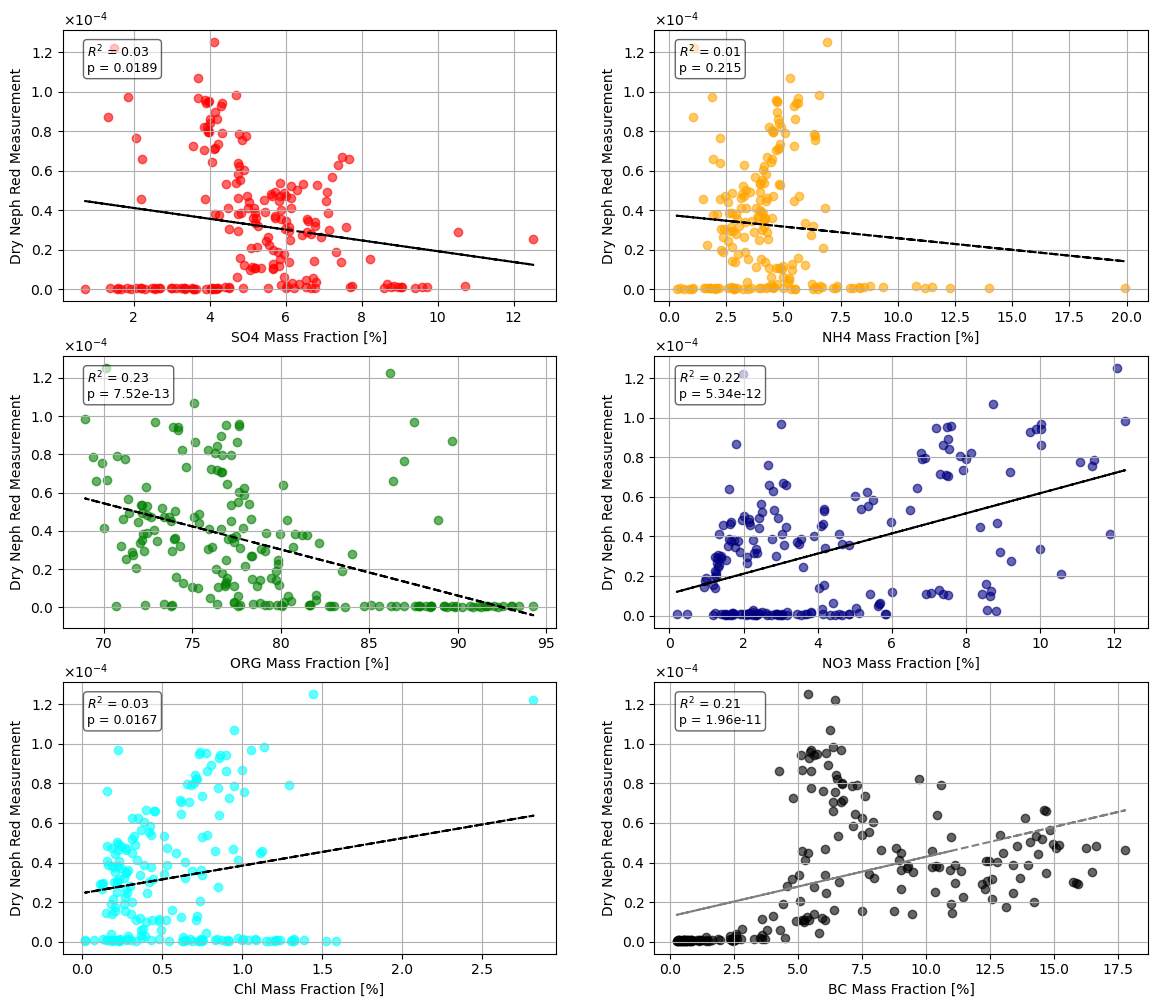

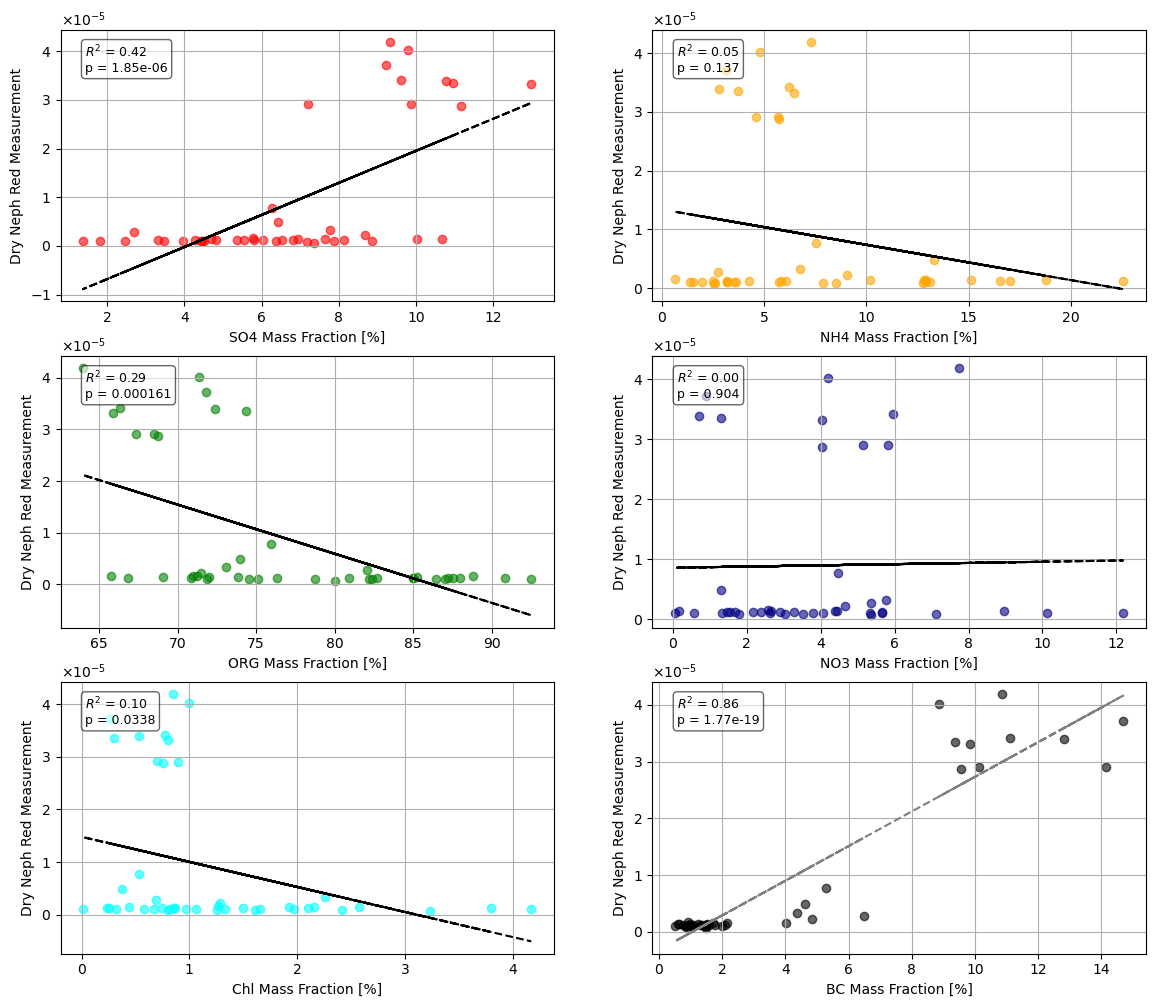

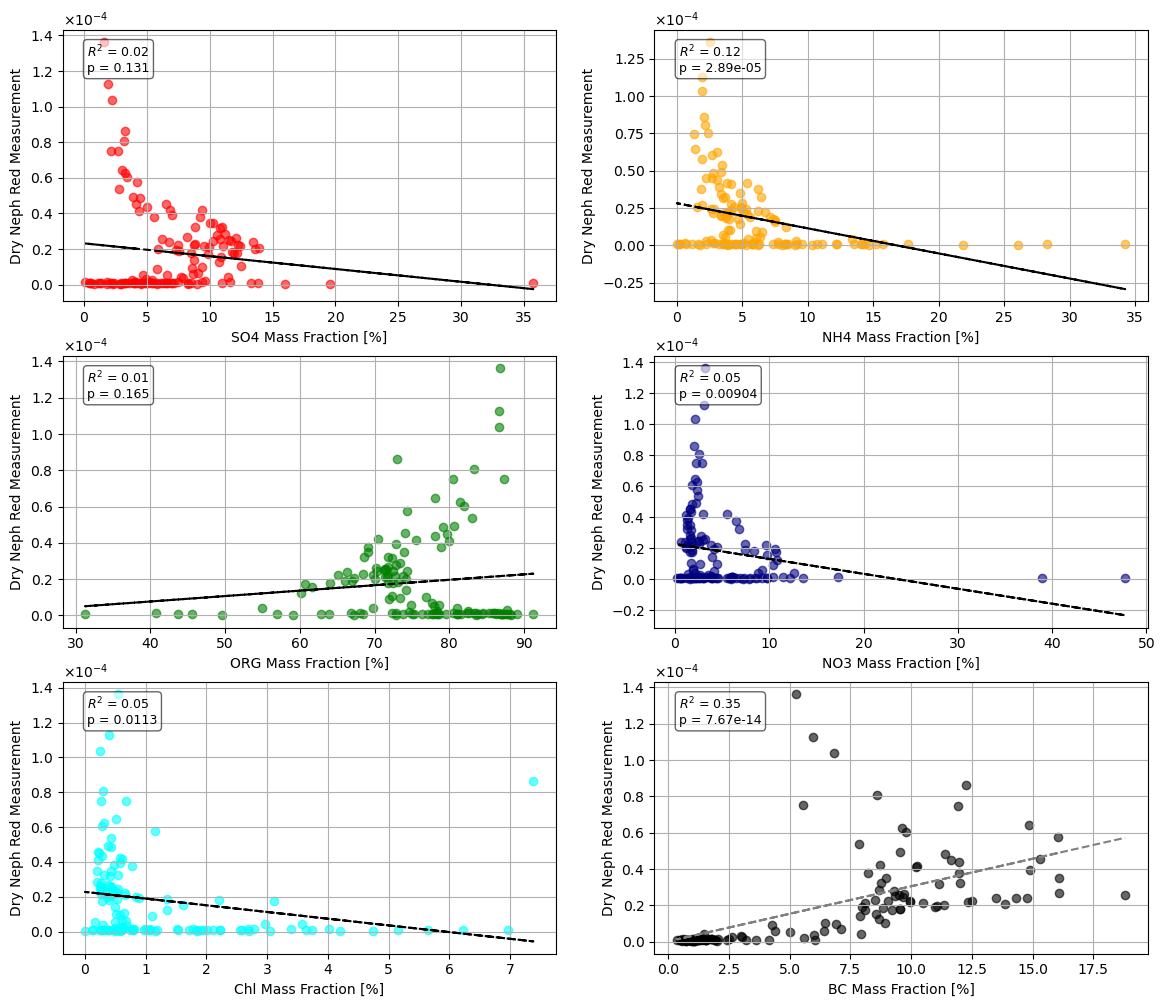

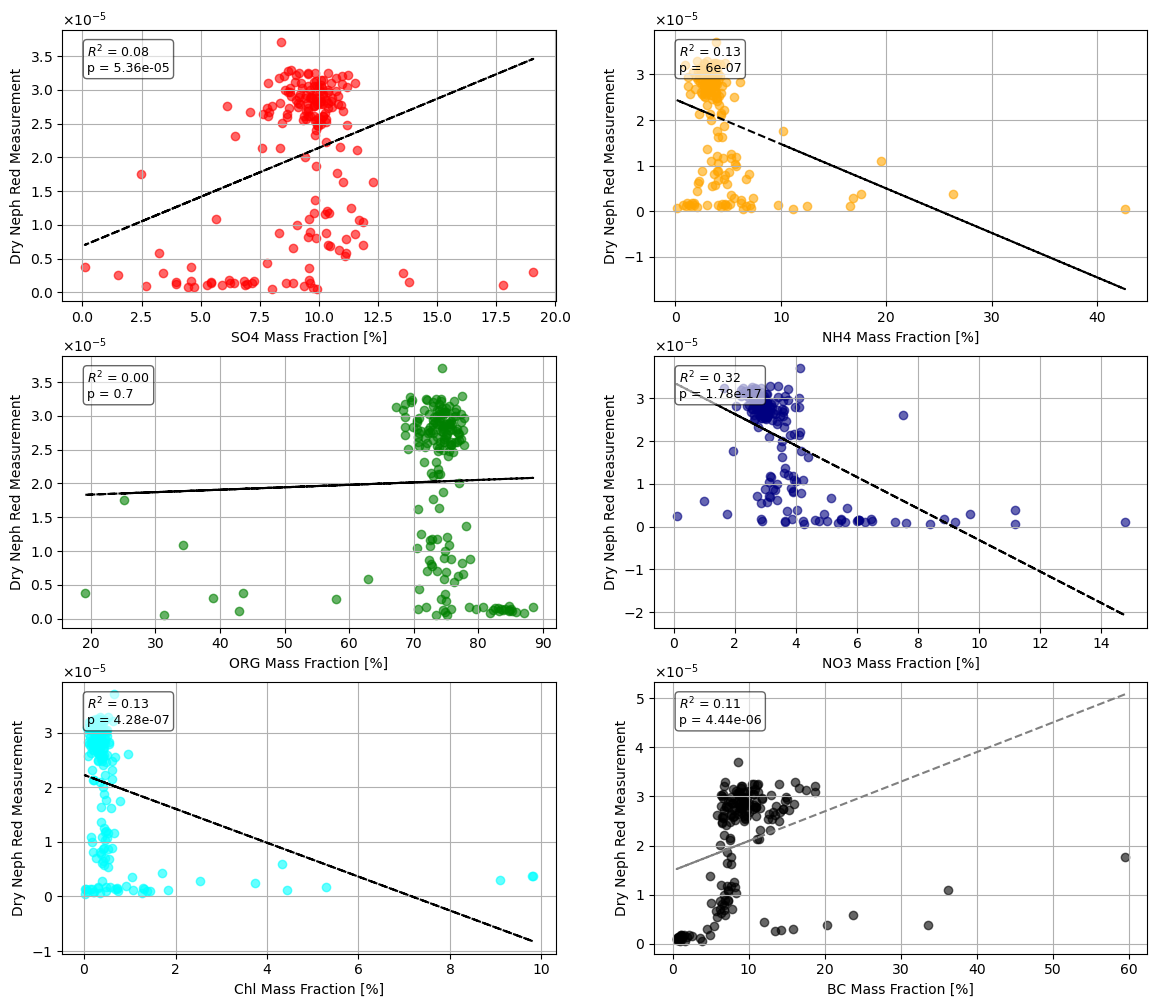

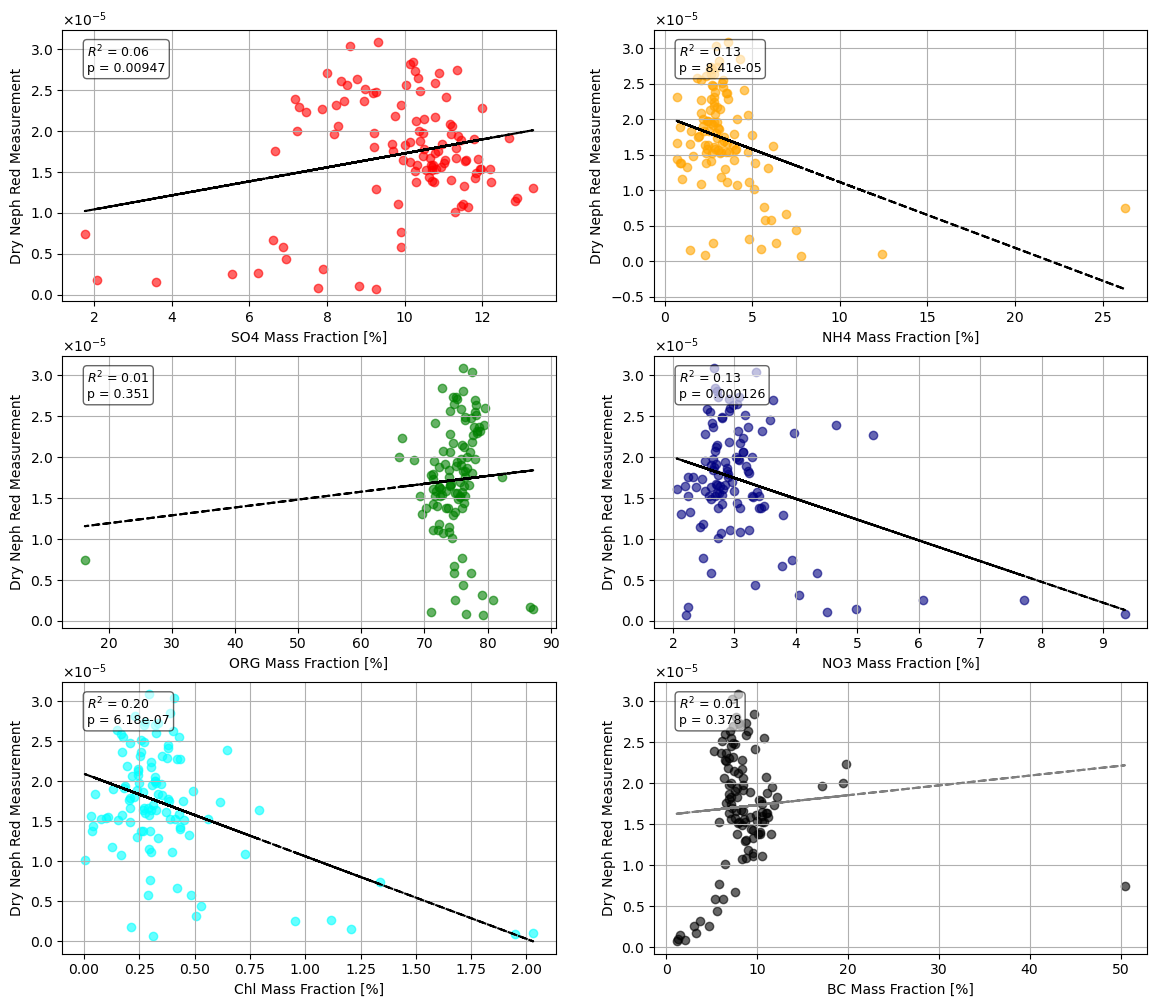

In [35]:
# List to store results
results = []


# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file, flight_comments_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph,filtered_sum):

    #print(neph_file)
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    
    #ds_psap = xr.open_dataset(nc_file)

    #Calculate absortion efficiency 
    ds_test,neph,mass_frac,mass_frac_sp2 = Test_function_v2(ds_ams,ds_neph,ds_sp2)
    
    time_neph = neph['time']
    time_mass_ams = mass_frac['time']
    time_mass_sp2 = mass_frac_sp2['time']
    
    matching_times_ams = np.intersect1d(time_mass_ams.values, time_neph.values)
    matching_times_sp2 = np.intersect1d(time_mass_sp2.values, time_neph.values)
    
    
    # Step 3: Select only matching times from both datasets
    mass_fraction_aligned_ams = mass_frac.sel(time=matching_times_ams)
    neph_aligned_ams = neph.sel(time=matching_times_ams)
    # Step 3: Select only matching times from both datasets
    mass_fraction_aligned_sp2 = mass_frac_sp2.sel(time=matching_times_sp2)
    neph_aligned_sp2 = neph.sel(time=matching_times_sp2)

    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    # Extract the date in yyyymmdd format
    date_match = re.search(r'(\d{8})', nc_file)
    if date_match:
        date_str = date_match.group(1)
        flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
    else:
        flight_date = "Unknown"

#    plot_mass_frac_flights( 
#        flight_number=flight_number,
#        flight_date = flight_date,
#        mass_frac_ams=mass_fraction_aligned_ams,
#        psap_ams=neph_aligned_ams,
#        mass_frac_sp2=mass_fraction_aligned_sp2,
#        psap_sp2=neph_aligned_sp2)
    plot_mass_frac_flights_lin_regress( 
        flight_number=flight_number,
        flight_date = flight_date,
        mass_frac_ams=mass_fraction_aligned_ams,
        psap_ams=neph_aligned_ams,
        mass_frac_sp2=mass_fraction_aligned_sp2,
        psap_sp2=neph_aligned_sp2)
